In [1]:
# %%
%load_ext autoreload
%autoreload 2
import json
import os
import subprocess
from pathlib import Path

import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display


ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "go.mod").exists() and (p / "cmd" / "ckks_offline").exists()
)
OUT = ROOT / "output"
OUT.mkdir(parents=True, exist_ok=True)
OFFLINE_CACHE = OUT / "ckks_cache"
CFG_PATH = OUT / "ckks_config.json"

ENV = {
    **os.environ,
    "GOMODCACHE": str(ROOT / ".gomodcache"),
    "GOCACHE": str(ROOT / ".gocache"),
}


def load_cfg() -> dict:
    return json.loads(CFG_PATH.read_text())


def save_cfg(cfg: dict) -> None:
    CFG_PATH.write_text(json.dumps(cfg, indent=2))
    print("Wrote", CFG_PATH)


def go_run(name: str, *, stream: bool = False) -> None:
    cmd = ["go", "run", f"./cmd/{name}"]
    print("Running:", " ".join(cmd))
    if stream:
        proc = subprocess.Popen(
            cmd,
            cwd=ROOT,
            env=ENV,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        if proc.stdout is not None:
            for line in proc.stdout:
                print(line, end="")
        proc.wait()
        return

    res = subprocess.run(cmd, cwd=ROOT, env=ENV, capture_output=True, text=True)
    if res.stdout:
        print(res.stdout)


### 1. Set configuration



In [2]:
# Set configuration

cfg = {
    # Inverted pendulum parameters
    "m": 0.2, "l": 0.5, "g": 9.81,
    # Sampling time
    "dt": 0.05,
    # Prediction horizon
    "N": 10,
    # Weight matrices
    "QDiag": [50.0, 5.0], "RDiag": [0.1], "QfScale": 2.0,
    # Initial state
    "x0": [0.3, 0.1],
    # Constraints
    "thetaMax": 0.5, "omegaMax": 0.8, "uMax": 1.0,
    # Variational MPC parameters
    "sigma0": 0.25, "lambda": 0.1, "K": 240,
    # Encryption parameters (satisfies 128-bit security)
    "logN": 13, "logQ": [33, 30, 30, 30], "logP": [35], "logDefaultScale": 30,
    "chebOrder": 3, "chebBound": 5.0, "chebEta": 500.0,
    # Total iteration
    "T": 40,
    # Paralleism
    "nWorkers": 4
}

save_cfg(cfg)

Wrote /Users/jihoonsuh/Documents/cdc2026/Variational-Encrypted-Model-Predictive-Control/GoVempc/output/ckks_config.json


### 2. Run Offline protocol (Algorithm 1)

In [3]:
# Choose whether to regenerate offline cache files
RUN_OFFLINE = True
# RUN_OFFLINE = False

cfg = load_cfg()
print(f"Offline config: K={cfg['K']}, nWorkers={cfg.get('nWorkers', 1)}, K_chunk={cfg['K'] // cfg.get('nWorkers', 1)}")
if RUN_OFFLINE:
    go_run("ckks_offline")
else:
    print(f"Skipping offline phase. Using saved cache in {OFFLINE_CACHE}")


Offline config: K=240, nWorkers=4, K_chunk=60
Running: go run ./cmd/ckks_offline
Slot width: 60, slots needed per worker: 3600
L_U dims: 10x10
Gamma dims: 60x10
CKKS slots: 4096, K: 240, nWorkers: 4, K_chunk: 60, T: 40
Client offline time: 114.446 ms
Cloud offline time: 135201.079 ms



### 3. Run Online Protocol (Algorithm 2)


In [4]:
cfg = load_cfg()
print(f"Online config: K={cfg['K']}, nWorkers={cfg.get('nWorkers', 1)}, K_chunk={cfg['K'] // cfg.get('nWorkers', 1)}")
go_run("ckks_online", stream=True)

Online config: K=240, nWorkers=4, K_chunk=60
Running: go run ./cmd/ckks_online
go: downloading golang.org/x/tools v0.38.0

ckks_online [=---------------------------]   2% 1/40 eta 00:01
ckks_online [====------------------------]  15% 6/40 eta 00:01
ckks_online [========--------------------]  28% 11/40 eta 00:00
ckks_online [===========-----------------]  40% 16/40 eta 00:00
ckks_online [==============--------------]  50% 20/40 eta 00:00
ckks_online [=================-----------]  60% 24/40 eta 00:00
ckks_online [====================--------]  70% 28/40 eta 00:00
ckks_online [======================------]  80% 32/40 eta 00:00
ckks_online [=========================---]  90% 36/40 eta 00:00
ckks_online [============================] 100% 40/40 eta 00:00
Control iteration time mean/std: 30.766 ms / 3.382 ms
Saved CKKS MPC outputs to output


### 4. Run unencrypted variational MPC for comparison

In [5]:
cfg = load_cfg()
go_run("unencrypted")

dt = float(cfg["dt"])
theta_max = float(cfg["thetaMax"])
omega_max = float(cfg["omegaMax"])
u_max = float(cfg["uMax"])

xs_var = np.loadtxt(OUT / "xs_variational.csv", delimiter=",", ndmin=2)
us_var = np.loadtxt(OUT / "us_variational.csv", delimiter=",", ndmin=2)

Running: go run ./cmd/unencrypted
Standard MPC
  runtime: 10ms
  cost:    34.237244
  viol:    (x=0.000000, u=0.000123)
Variational MPC
  runtime: 14ms
  cost:    34.404918
  viol:    (x=0.000000, u=0.000000)
  w_sum mean: 233.225000
  accept mean: 233.225000

Saved CSV outputs to output
Saved plots to output/plots



### 5. Plot


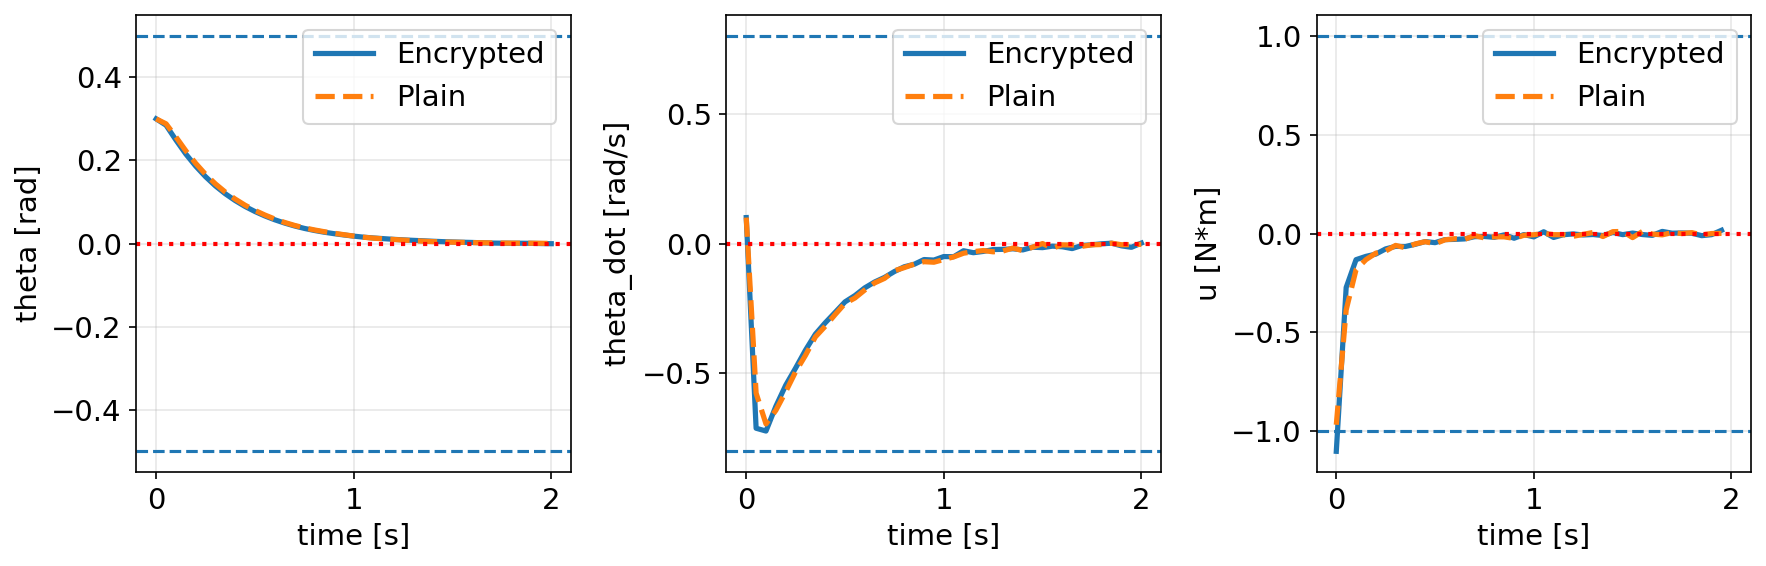

Saved overlay plot to /Users/jihoonsuh/Documents/cdc2026/Variational-Encrypted-Model-Predictive-Control/GoVempc/output/overlay_plot.png


In [6]:
cfg = load_cfg()

dt = float(cfg["dt"])
theta_max = float(cfg["thetaMax"])
omega_max = float(cfg["omegaMax"])
u_max = float(cfg["uMax"])

xs_ckks = np.loadtxt(OUT / "xs_ckks.csv", delimiter=",", ndmin=2)
us_ckks = np.loadtxt(OUT / "us_ckks.csv", delimiter=",", ndmin=2)
xs_plain = np.loadtxt(OUT / "xs_variational.csv", delimiter=",", ndmin=2)
us_plain = np.loadtxt(OUT / "us_variational.csv", delimiter=",", ndmin=2)

t_ckks = np.arange(xs_ckks.shape[0]) * dt
t_plain = np.arange(xs_plain.shape[0]) * dt
tu_ckks = np.arange(us_ckks.shape[0]) * dt
tu_plain = np.arange(us_plain.shape[0]) * dt

plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
ax = ax.ravel()

def add_bounds(a, bound):
    a.axhline(0.0, color="red", linestyle=":", linewidth=2.0)
    a.axhline(+bound, linestyle="--")
    a.axhline(-bound, linestyle="--")

ax[0].plot(t_ckks, xs_ckks[:, 0], label="Encrypted", linewidth=2.5)
ax[0].plot(t_plain, xs_plain[:, 0], label="Plain", linewidth=2.5, linestyle="--")
add_bounds(ax[0], theta_max)
ax[0].set_ylabel("theta [rad]")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(t_ckks, xs_ckks[:, 1], label="Encrypted", linewidth=2.5)
ax[1].plot(t_plain, xs_plain[:, 1], label="Plain", linewidth=2.5, linestyle="--")
add_bounds(ax[1], omega_max)
ax[1].set_ylabel("theta_dot [rad/s]")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

ax[2].plot(tu_ckks, us_ckks[:, 0], label="Encrypted", linewidth=2.5)
ax[2].plot(tu_plain, us_plain[:, 0], label="Plain", linewidth=2.5, linestyle="--")
add_bounds(ax[2], u_max)
ax[2].set_ylabel("u [N*m]")
ax[2].grid(True, alpha=0.3)
ax[2].legend()

for a in ax:
    a.set_xlabel("time [s]")

plt.tight_layout()
plot_path = OUT / "overlay_plot.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(plot_path)))
print(f"Saved overlay plot to {plot_path.resolve()}")
